# Задача 1

In [1]:
import logging
from typing import Optional, Any

logging.getLogger().setLevel(logging.INFO)

In [2]:
class Car:
  def __init__(self, model: str, mileage: float, is_parked: bool = False, consumption: float = 10):
    self.model = model
    self.mileage = mileage
    self.is_parked = is_parked
    self.consumption = consumption

  def drive(self, distance: float) -> None:
    if not self.is_parked:
      self.mileage += distance
      logging.info(f"Car drived {distance} miles")
    else:
      logging.warning("Car can't drive into garage")

  def get_info(self) -> dict[str, Any]:
    car_info = {
        "model": self.model,
        "mileage": self.mileage,
        "status": self.is_parked
    }
    logging.info("-"*20)
    for key, value in car_info.items():
      logging.info(f"{key}: {value}")
    logging.info("-"*20)
    return car_info


In [3]:
class ElectricCar(Car):
  def __init__(self, model: str, mileage: float, battery: float = 100, is_parked: bool = False, consumption: float = 10):
    super().__init__(model=model, mileage=mileage, is_parked=is_parked, consumption=consumption)
    self.battery = battery
    if self.battery > 100:
      self.battery = 100
    elif self.battery < 0:
      self.battery = 0

  def charge(self):
    if self.is_parked:
      self.battery = 100
      logging.info("Car has been chrged")
    else:
      logging.warning("Car not in garage")

  def drive(self, distance: float):
    availiable_distance = min(self.battery * self.consumption, distance)
    super().drive(distance=availiable_distance)
    self.battery -= availiable_distance / self.consumption

In [4]:
class Garage:
  def __init__(self, capacity: int, cars: Optional[list[Car]] = None):
    self.capacity = capacity
    self.cars = list() if cars is None else cars

  def add_car(self, car: Car) -> None:
    if car.is_parked:
      logging.warning("Car already parked")
      return

    if self.capacity == len(self.cars):
      logging.warning(f"Garage is full. Car {car.model} hasn't been parked.")
      return

    self.cars.append(car)
    car.is_parked = True
    logging.info(f"Car {car.model} has been parked")

  def remove_car(self, car: Car) -> None:
    for parking_space_number in range(len(self.cars)):
      if car is self.cars[parking_space_number]:
        car.is_parked = False
        del self.cars[parking_space_number]
        logging.info("Car succeessfully left garage")

  def show_list_cars(self) -> None:
    logging.info("-"*20)
    logging.info(f"Garage capacity: {self.capacity}; Current count of cars: {len(self.cars)}")
    for car in self.cars:
      logging.info(car.model)
    logging.info("-"*20)

In [5]:
car_1 = Car(model="Toyota Corolla", mileage=15000)
car_2= ElectricCar(model="Tesla Model 3", mileage=50000, battery=80)
car_3 = ElectricCar(model="Volkswagen ID.6", mileage=7000, battery=25)

garage = Garage(capacity=2)

In [6]:
garage.add_car(car_1)
garage.add_car(car_2)
garage.add_car(car_3)

INFO:root:Car Toyota Corolla has been parked
INFO:root:Car Tesla Model 3 has been parked


In [7]:
car_1.drive(100)
car_2.charge()
car_3.charge()

INFO:root:Car has been chrged


In [8]:
garage.remove_car(car_2)

INFO:root:Car succeessfully left garage


In [9]:
car_2.drive(450)
car_2.get_info()

INFO:root:Car drived 450 miles
INFO:root:--------------------
INFO:root:model: Tesla Model 3
INFO:root:mileage: 50450
INFO:root:status: False
INFO:root:--------------------


{'model': 'Tesla Model 3', 'mileage': 50450, 'status': False}

In [10]:
garage.show_list_cars()

INFO:root:--------------------
INFO:root:Garage capacity: 2; Current count of cars: 1
INFO:root:Toyota Corolla
INFO:root:--------------------


# Задача 2

In [11]:
import numpy as np
from random import randint
import matplotlib.pyplot as plt
from collections import Counter

In [12]:
class DataPoint:
    def __init__(self, coordinates, label):
        self.coordinates = np.array(coordinates)
        self.label = label
        self.is_neighbor = False

    def distance_to(self, other):
        return np.linalg.norm(self.coordinates - other.coordinates)

In [13]:
class KNNClassifier:
    def __init__(self, k, n, m):
        self.k = k  # количество ближайших соседей
        self.n = n  # размерность пространства
        self.m = m  # количество классов
        self.data_points = []

    def add_data_point(self, data_point):
        if len(data_point.coordinates) != self.n:
            raise ValueError("Размерность координат точки не соответствует размерности пространства.")
        self.data_points.append(data_point)

    def predict(self, new_point):
        distances = [(dp, dp.distance_to(new_point)) for dp in self.data_points]
        distances.sort(key=lambda x: x[1])
        neighbors = distances[:self.k]
        for neighbor, _ in neighbors:
          neighbor.is_neighbor = True

        votes = Counter(neighbor[0].label for neighbor in neighbors)
        most_common = votes.most_common()

        if len(most_common) > 1 and most_common[0][1] == most_common[1][1]:
            neighbors.pop()
            votes = Counter(neighbor[0].label for neighbor in neighbors)
            most_common = votes.most_common()

        if len(most_common) > 1 and most_common[0][1] == most_common[1][1]:
            weighted_votes = {label: sum(1 / neighbor[1] for neighbor in neighbors if neighbor[0].label == label)
                              for label in votes}
            predicted_label = max(weighted_votes, key=weighted_votes.get)
        else:
            predicted_label = most_common[0][0]

        return predicted_label

    def visualize(self, new_point: DataPoint):
        if self.n != 2:
            raise ValueError("Визуализация возможна только для двумерного случая (n=2).")

        colors = plt.cm.get_cmap('Spectral', self.m)
        for point in self.data_points:
          plt.scatter(point.coordinates[0], point.coordinates[1], c=colors(point.label), s=100 if point.is_neighbor else 50)
          plt.annotate(point.label, (point.coordinates[0], point.coordinates[1]), textcoords="offset points", xytext=(5, 5), ha='center')


        plt.scatter(new_point.coordinates[0], new_point.coordinates[1], marker='x', s=100, c=colors(new_point.label))

        plt.title('KNN Classification')
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.show()

/tmp/ipython-input-266159455.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Spectral', self.m)
/tmp/ipython-input-266159455.py:43: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(point.coordinates[0], point.coordinates[1], c=colors(point.label), s=100 if point.is_neighbor else 50)
/tmp/ipython-input-266159455.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & 

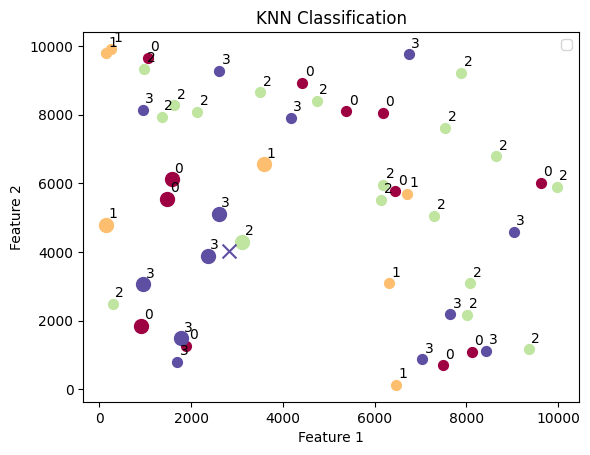

Предсказанный класс для точки [2834 4017]: 3


In [14]:
dots_cnt = 10_000
k, n, m = 10, 2, 4

knn = KNNClassifier(k=k, n=n, m=m)

for i in range(50):
  knn.add_data_point(DataPoint([randint(0, dots_cnt), randint(0, dots_cnt)], randint(0, m-1)))

new_point = DataPoint([randint(0, dots_cnt), randint(0, dots_cnt)], None)
new_point.label = knn.predict(new_point)

knn.visualize(new_point)
print(f"Предсказанный класс для точки {new_point.coordinates}: {new_point.label}")